# 01 · Vanilla SINDy

**SINDy** (Sparse Identification of Nonlinear Dynamics, Brunton et al. 2016):

1. Estimate the derivative $\dot X$ from the data (finite differences).
2. Build a candidate library $\Theta(X)$.
3. Solve $\dot X = \Theta(X)\,\Xi$ for a **sparse** $\Xi$ via sequentially-thresholded
   least squares (**STLSQ**): least squares, zero out small coefficients, repeat.

We use the **Lotka–Volterra** system, whose true equations are
$$\dot x = 1.0\,x - 0.1\,xy, \qquad \dot y = -1.5\,y + 0.075\,xy.$$

In [ ]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the shared tutorial package (src/sparse_demos) importable regardless of
# whether the notebook is launched from notebooks/ or the repo root.
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
%matplotlib inline

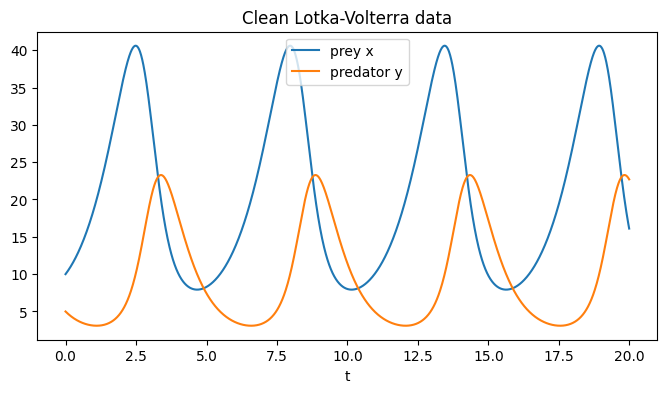

In [2]:
from sparse_demos import systems, plotting
import pysindy as ps

# Clean data first.
t, X = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01, noise_std=0.0)
dt = t[1] - t[0]
plotting.plot_trajectories(t, X, labels=["prey x", "predator y"],
                           title="Clean Lotka-Volterra data"); plt.show()

## Fit with pysindy

A degree-2 polynomial library plus an STLSQ optimizer with a coefficient threshold.

In [3]:
model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=2),
    optimizer=ps.STLSQ(threshold=0.05),
)
model.fit(X, t=dt, feature_names=["x", "y"])
print("Recovered model (clean data):")
model.print()
print("\nTrue model:\n(x)' = 1.000 x + -0.100 x y\n(y)' = -1.500 y + 0.075 x y")

Recovered model (clean data):
(x)' =  1.000 x + -0.100 x y
(y)' = -1.500 y +  0.075 x y

True model:
(x)' = 1.000 x + -0.100 x y
(y)' = -1.500 y + 0.075 x y


iThat is an essentially exact recovery. To demystify the optimizer, here is the same
idea implemented with the helpers in `sparse_demos.solvers`.

In [5]:
from sparse_demos import libraries, solvers

# Estimate derivatives by finite differences, build library, run STLSQ ourselves.
dXdt = np.gradient(X, dt, axis=0)
Theta, names = libraries.polynomial_library(X, degree=2)
Xi = solvers.stlsq(Theta, dXdt, threshold=0.05)
solvers.print_model(Xi, names, target_names=["x'", "y'"])

x' = +1.000 x0 -0.100 x0 x1
y' = -1.500 x1 +0.075 x0 x1


## Noise

SINDy estimates $\dot X$ by differentiating the data — and differentiation
*amplifies noise*. Watch what a modest amount of measurement noise does.

In [15]:
noise_std=0.1 # set standard deviation of noise
tn, Xn = systems.simulate("lotka_volterra", t_span=(0, 30), dt=0.01,
                          noise_std = noise_std, seed=1)

# 1) Split data into train / validation - validatoin is for use later in determining optimal thereshold
split_idx = int(0.6 * len(t))
t_train, X_train = tn[:split_idx], Xn[:split_idx]
t_val,   X_val   = tn[split_idx:], Xn[split_idx:]

noisy = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2),
                 optimizer=ps.STLSQ(threshold=0.05))
noisy.fit(X_train, t=dt, feature_names=["x", "y"])
print(f"Recovered model from NOISY data (std={noise_std}):")
noisy.print()
print("\n-> spurious terms creep in; at higher noise.")

Recovered model from NOISY data (std=0.1):
(x)' = -0.070 1 +  0.997 x + -0.100 x y
(y)' = -1.502 y +  0.075 x y

-> spurious terms creep in; at higher noise.


## Threshold is not know ahead of time.

Here we sweep the threshold and test on out of sample data to determine an optimal threshold


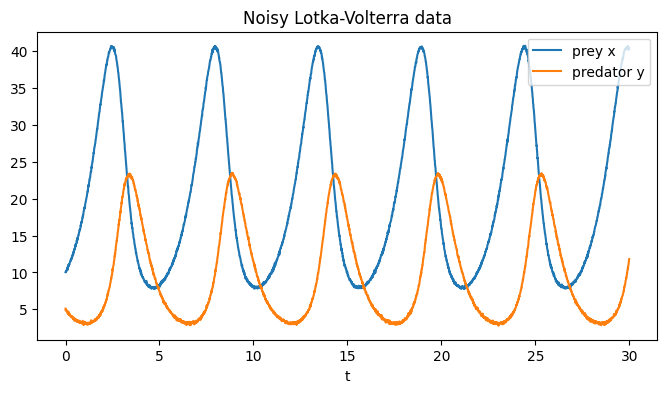

In [12]:
# Generate new data for t=30 time with tiny amount of noise

#tn, Xn = systems.simulate("lotka_volterra", t_span=(0, 30), dt=0.01,
#                          noise_std=0.1, seed=1)

plotting.plot_trajectories(tn, Xn, labels=["prey x", "predator y"],
                           title="Noisy Lotka-Volterra data"); plt.show()

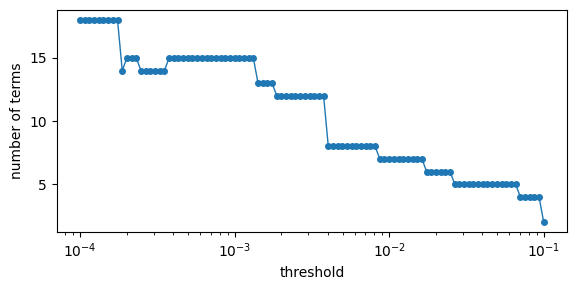

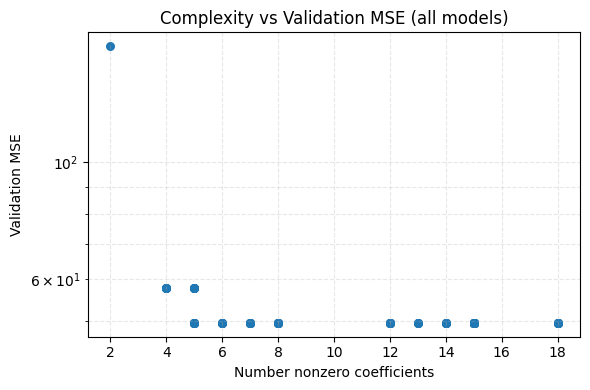

In [13]:

# Compute true derivative on validation set using finite differences
dXdt_val = np.gradient(X_val, t_val, axis=0)
# 2) Sweep thresholds
thresholds = np.logspace(-4, -1, 100)  # tune range for your problem
results = []
for thr in thresholds:
    opt = ps.STLSQ(threshold=thr)
    model = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt)
    model.fit(X_train, t=t_train)
    # Predict the derivative f(X) on validation set
    dXdt_pred = model.predict(X_val)
    mse = mean_squared_error(dXdt_val.reshape(-1), dXdt_pred.reshape(-1))
    # Count nonzero coefficients (total across all equations)
    # model.coefficients() returns a 2D array with shape (n_features, n_outputs)
    coefs = np.array(model.coefficients())
    nnz = np.sum(np.abs(coefs) > 1e-8)
    results.append({'threshold': thr, 'nnz': int(nnz), 'mse': float(mse), 'model': model})


# threshold vs #terms plot
ths = np.array([r['threshold'] for r in results])
nnz = np.array([r['nnz'] for r in results])
order = np.argsort(ths)
ths, nnz = ths[order], nnz[order]

plt.figure(figsize=(6,3))
plt.plot(ths, nnz, 'o-', lw=1, ms=4, color='C0')
plt.xscale('log')
plt.xlabel('threshold')
plt.ylabel('number of terms')
plt.tight_layout()
plt.show()


# 4) Plot results and Pareto front
nnz = np.array([r['nnz'] for r in results])
mse = np.array([r['mse'] for r in results])

plt.figure(figsize=(6,4))
plt.scatter(nnz, mse, c='C0', s=30)
plt.yscale('log')
plt.xlabel('Number nonzero coefficients')
plt.ylabel('Validation MSE')
plt.title('Complexity vs Validation MSE (all models)')
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# minimal: print unique models with threshold range (min - max)
groups = {}
for i, r in enumerate(results):
    coefs = np.array(r['model'].coefficients())
    key = tuple(np.round(coefs.ravel(), 8))
    groups.setdefault(key, []).append(i)

for key, idxs in groups.items():
    i = idxs[0]
    ths = np.array([results[j]['threshold'] for j in idxs])
    thmin, thmax = ths.min(), ths.max()
    rng = f"{thmin:.2e}" if thmin == thmax else f"{thmin:.2e} - {thmax:.2e}"
    print(f"Unique model (threshold range: {rng})")
    print(f"  nnz = {results[i]['nnz']}, mse = {results[i]['mse']:.3e}")
    results[i]['model'].print()
    print('-' * 60)

Unique model (threshold range: 1.00e-04 - 1.75e-04)
  nnz = 18, mse = 4.965e+01
(x0)' =  8.413 1 +  0.833 x0 +  1.228 x1 +  0.016 x0^2 + -0.475 x0 x1 + -0.005 x1^2 +  0.005 x0^2 x1 +  0.006 x0 x1^2 +  0.002 x1^3
(x1)' = -1.270 1 +  0.110 x0 + -1.294 x1 + -0.002 x0^2 +  0.060 x0 x1 + -0.009 x1^2
------------------------------------------------------------
Unique model (threshold range: 1.87e-04 - 3.51e-04)
  nnz = 14, mse = 4.965e+01
(x0)' =  8.413 1 +  0.833 x0 +  1.228 x1 +  0.016 x0^2 + -0.475 x0 x1 + -0.005 x1^2 +  0.005 x0^2 x1 +  0.006 x0 x1^2 +  0.002 x1^3
(x1)' = -0.429 1 +  0.036 x0 + -1.487 x1 + -0.001 x0^2 +  0.074 x0 x1
------------------------------------------------------------
Unique model (threshold range: 2.01e-04 - 1.32e-03)
  nnz = 15, mse = 4.965e+01
(x0)' =  8.413 1 +  0.833 x0 +  1.228 x1 +  0.016 x0^2 + -0.475 x0 x1 + -0.005 x1^2 +  0.005 x0^2 x1 +  0.006 x0 x1^2 +  0.002 x1^3
(x1)' = -0.977 1 +  0.072 x0 + -1.429 x1 + -0.001 x0^2 +  0.074 x0 x1 + -0.002 x1^2
----

Next, try what happens when the std = 0.3 or higher.

**Takeaways.** Vanilla SINDy is fast and exact on clean polynomial dynamics. The sparsity cannot be known ahead of time and requires separate tuning for each equation.

A reliance on numerical derivatives makes it fragile to noise.

Next: **Weak SINDy** removes that derivative step. → `02_weak_sindy.ipynb`